# Akeed Restaurant Recommendation — EDA
Following `docs/eda_checklist.md`.

Core tables: `orders` (customer_id x vendor_id interaction), `train_customers`, `train_locations`, `vendors`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

DATA_DIR = "../../data/raw/food/akeed"
sns.set_theme(style="whitegrid")

## 1. Load & Overview

In [2]:
orders = pd.read_csv(f"{DATA_DIR}/orders.csv", low_memory=False)
customers = pd.read_csv(f"{DATA_DIR}/train_customers.csv")
locations = pd.read_csv(f"{DATA_DIR}/train_locations.csv")
vendors = pd.read_csv(f"{DATA_DIR}/vendors.csv")

for name, df in [("orders", orders), ("customers", customers), ("locations", locations), ("vendors", vendors)]:
    print(name, df.shape)

orders (135303, 26)
customers (34674, 8)
locations (59503, 5)
vendors (100, 59)


In [3]:
orders.head()

,akeed_order_id,customer_id,item_count,grand_total,payment_mode,promo_code,vendor_discount_amount,promo_code_discount_percentage,is_favorite,is_rated,...,driver_accepted_time,ready_for_pickup_time,picked_up_time,delivered_time,delivery_date,vendor_id,created_at,LOCATION_NUMBER,LOCATION_TYPE,CID X LOC_NUM X VENDOR
0,163238.0,92PEE24,1.0,7.6,2,NaN,0.0,NaN,NaN,No,...,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,105,2019-08-01 05:30:16,0,NaN,92PEE24 X 0 X 105
1,163240.0,QS68UD8,1.0,8.7,1,NaN,0.0,NaN,NaN,No,...,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,294,2019-08-01 05:31:10,0,Work,QS68UD8 X 0 X 294
2,163241.0,MB7VY5F,2.0,14.4,1,NaN,0.0,NaN,NaN,No,...,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,83,2019-08-01 05:31:33,0,NaN,MB7VY5F X 0 X 83
3,163244.0,KDJ951Y,1.0,7.1,1,NaN,0.0,NaN,NaN,No,...,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,90,2019-08-01 05:34:54,0,Home,KDJ951Y X 0 X 90
4,163245.0,BAL0RVT,4.0,27.2,1,NaN,0.0,NaN,NaN,No,...,NaN,NaN,NaN,NaN,2019-07-31 05:30:00,83,2019-08-01 05:35:51,0,Work,BAL0RVT X 0 X 83


In [4]:
orders.dtypes

akeed_order_id                    float64
customer_id                           str
item_count                        float64
grand_total                       float64
payment_mode                        int64
promo_code                            str
vendor_discount_amount            float64
promo_code_discount_percentage    float64
is_favorite                           str
is_rated                              str
vendor_rating                     float64
driver_rating                     float64
deliverydistance                  float64
preparationtime                   float64
delivery_time                         str
order_accepted_time                   str
driver_accepted_time                  str
ready_for_pickup_time                 str
picked_up_time                        str
delivered_time                        str
delivery_date                         str
vendor_id                           int64
created_at                            str
LOCATION_NUMBER                   

## 2. Missing Values

In [5]:
(orders.isna().mean() * 100).round(1).sort_values(ascending=False)

promo_code                        96.8
delivery_time                     96.2
delivery_date                     73.7
vendor_rating                     66.6
driver_accepted_time              65.7
promo_code_discount_percentage    51.3
preparationtime                   41.1
picked_up_time                    38.0
ready_for_pickup_time             37.7
delivered_time                    36.6
LOCATION_TYPE                     36.1
order_accepted_time               35.7
is_favorite                       26.0
item_count                         5.1
akeed_order_id                     0.1
customer_id                        0.0
grand_total                        0.0
payment_mode                       0.0
is_rated                           0.0
vendor_discount_amount             0.0
driver_rating                      0.0
deliverydistance                   0.0
vendor_id                          0.0
created_at                         0.0
LOCATION_NUMBER                    0.0
CID X LOC_NUM X VENDOR   

In [6]:
(customers.isna().mean() * 100).round(1).sort_values(ascending=False)

dob                  91.2
language             39.2
gender               35.1
akeed_customer_id     0.0
status                0.0
verified              0.0
created_at            0.0
updated_at            0.0
dtype: float64

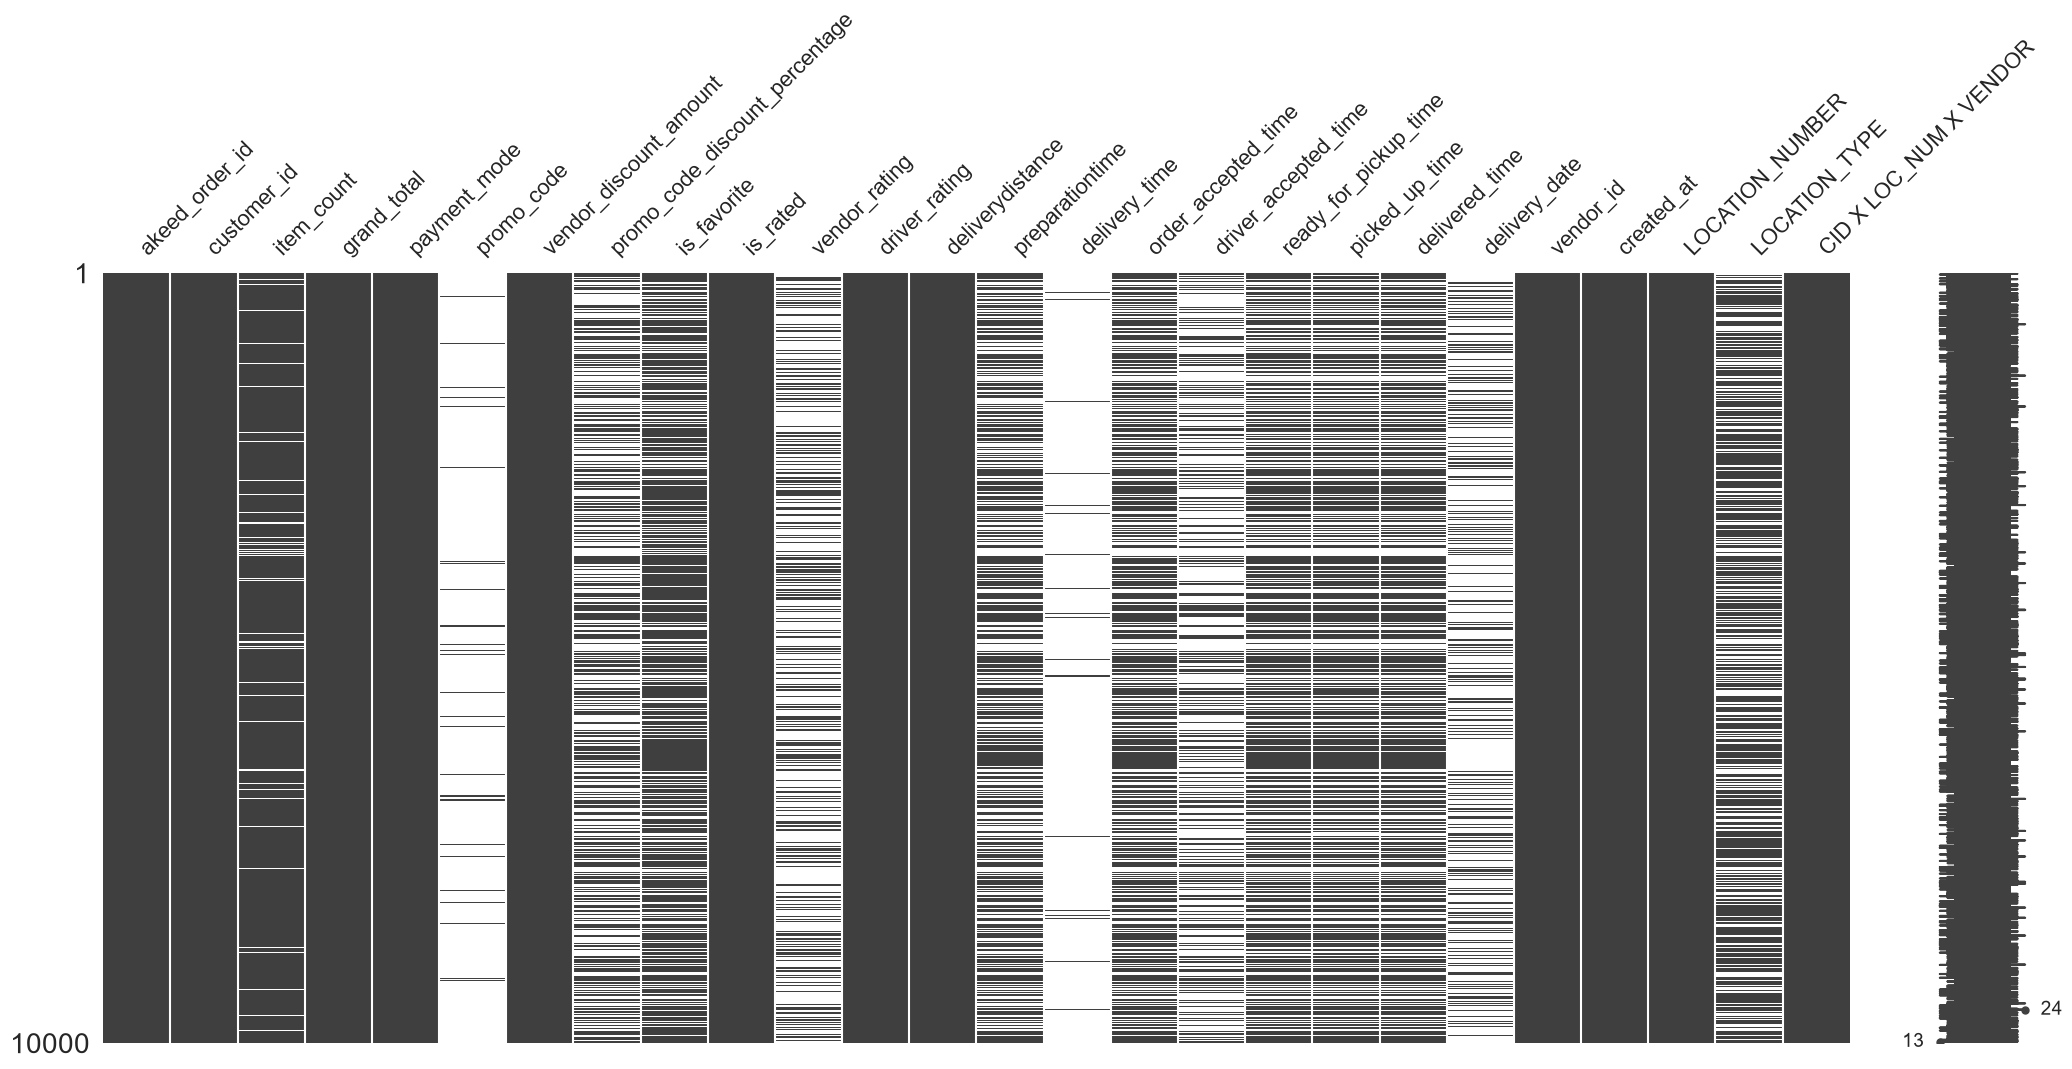

In [7]:
msno.matrix(orders.sample(10_000, random_state=0)); plt.show()

Decision: `vendor_rating`/`driver_rating` missing = unrated order, flag as feature (`is_rated` already exists) not drop. `promo_code`/`vendor_discount_amount` missing = no promo applied, fill 0/None. `dob` heavy missing in customers — drop as feature or impute cautiously, don't drop rows.

## 3. Duplicates

In [8]:
print("full-row dup orders:", orders.duplicated().sum())
print("dup akeed_order_id:", orders.duplicated(subset=["akeed_order_id"]).sum())
print("dup customer_id in customers table:", customers.duplicated(subset=["akeed_customer_id"]).sum())
print("dup vendor id in vendors table:", vendors.duplicated(subset=["id"]).sum())

full-row dup orders: 0
dup akeed_order_id: 81
dup customer_id in customers table: 151
dup vendor id in vendors table: 0


## 4. Univariate Analysis

In [9]:
orders[["grand_total", "item_count", "deliverydistance", "preparationtime"]].describe()

,grand_total,item_count,deliverydistance,preparationtime
count,135303.000000,128378.000000,135303.000000,79743.000000
mean,15.374513,2.405404,4.104255,43.181721
std,12.556177,1.645332,4.361884,7.107582
min,0.000000,1.000000,0.000000,25.000000
25%,8.200000,1.000000,0.000000,40.000000
50%,11.700000,2.000000,2.900000,45.000000
75%,18.500000,3.000000,7.920000,45.000000
max,783.800000,68.000000,19.810000,90.000000


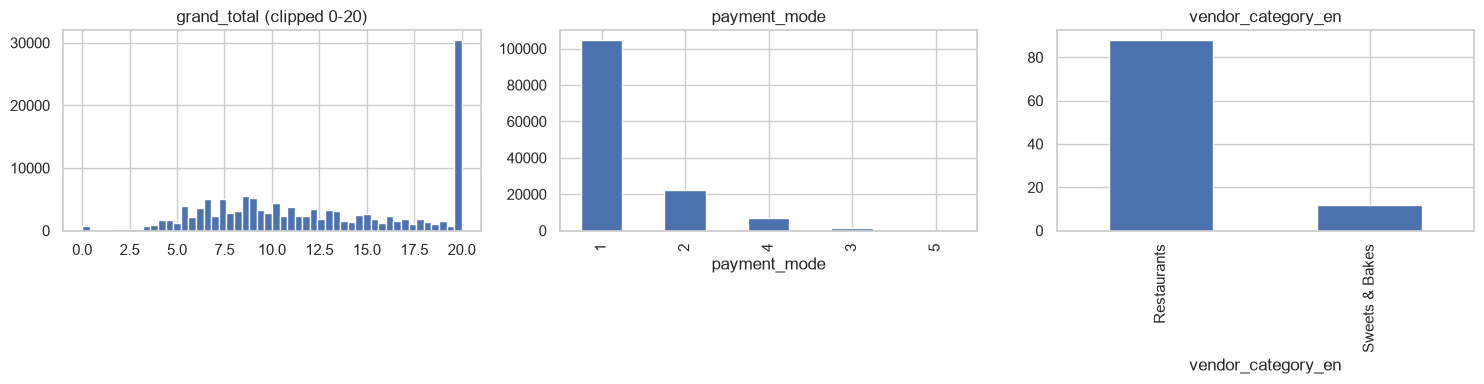

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
orders["grand_total"].clip(0, 20).hist(bins=50, ax=ax[0]); ax[0].set_title("grand_total (clipped 0-20)")
orders["payment_mode"].value_counts().plot(kind="bar", ax=ax[1]); ax[1].set_title("payment_mode")
vendors["vendor_category_en"].value_counts().plot(kind="bar", ax=ax[2]); ax[2].set_title("vendor_category_en")
plt.tight_layout(); plt.show()

## 5. Outliers

grand_total <= 0: 683
item_count == 0: 0
deliverydistance <= 0: 55613
deliverydistance > 50 km: 0


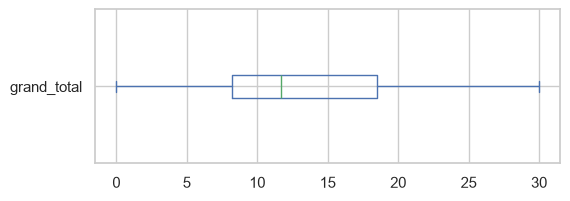

In [11]:
print("grand_total <= 0:", (orders["grand_total"] <= 0).sum())
print("item_count == 0:", (orders["item_count"] == 0).sum())
print("deliverydistance <= 0:", (orders["deliverydistance"] <= 0).sum())
print("deliverydistance > 50 km:", (orders["deliverydistance"] > 50).sum())
orders["grand_total"].clip(0, 30).plot(kind="box", vert=False, figsize=(6, 2)); plt.show()

## 6. Target Variable
Core task: predict which `vendor_id` a `customer_id` will order from (implicit, from `orders` join). No single labeled target column — target is constructed from the interaction table itself, same shape as competition's `LOCATION x VENDOR` pair test.

## 7. Bivariate / Correlation Analysis

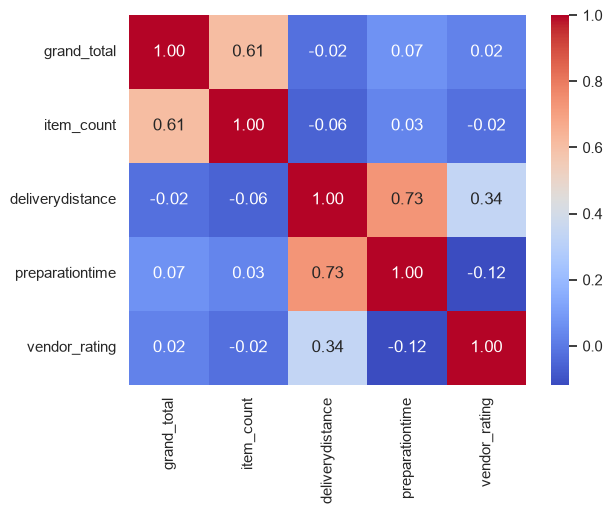

In [12]:
num_cols = ["grand_total", "item_count", "deliverydistance", "preparationtime", "vendor_rating"]
sns.heatmap(orders[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm"); plt.show()

## 8. Time-based Checks

created_at range: 2019-05-10 20:59:58 to 2020-02-29 23:52:14
unparseable created_at: 0


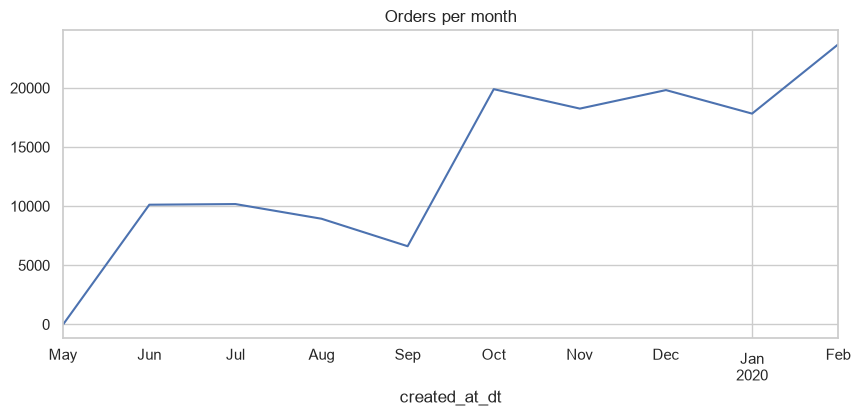

In [13]:
orders["created_at_dt"] = pd.to_datetime(orders["created_at"], errors="coerce")
print("created_at range:", orders["created_at_dt"].min(), "to", orders["created_at_dt"].max())
print("unparseable created_at:", orders["created_at_dt"].isna().sum())
orders.set_index("created_at_dt").resample("ME").size().plot(figsize=(10, 4), title="Orders per month")
plt.show()

## 9. Data Consistency

In [14]:
# Oman bounding box roughly lat 16-27, lon 51-60
bad_loc = ~locations["latitude"].between(16, 27) | ~locations["longitude"].between(51, 60)
print("locations outside Oman bbox:", bad_loc.sum(), f"({bad_loc.mean():.1%})")
print("customer_id in orders but not in customers table:", (~orders["customer_id"].isin(customers["akeed_customer_id"])).sum())
print("vendor_id in orders but not in vendors table:", (~orders["vendor_id"].isin(vendors["id"])).sum())

locations outside Oman bbox: 59503 (100.0%)


customer_id in orders but not in customers table: 3276
vendor_id in orders but not in vendors table: 0


Result: 100% of locations fall outside real Oman bbox — not a partial data-quality glitch, coordinates in this dataset are synthetic/jittered (privacy anonymization), not real GPS. Do not build real-world geo-distance features from `latitude`/`longitude` directly; treat as anonymized numeric feature only.

## 10. Feature Relationships for Recommendation Context

In [15]:
n_customers = orders["customer_id"].nunique()
n_vendors = orders["vendor_id"].nunique()
n_interactions = orders.drop_duplicates(subset=["customer_id", "vendor_id"]).shape[0]
sparsity = 1 - n_interactions / (n_customers * n_vendors)
print(f"customers={n_customers} vendors={n_vendors} unique(cust,vendor) pairs={n_interactions} sparsity={sparsity:.4%}")

customers=27445 vendors=100 unique(cust,vendor) pairs=71484 sparsity=97.3954%


vendors with <=5 orders: 0 (0.0%)
customers with only 1 order: 9919 (36.1%)


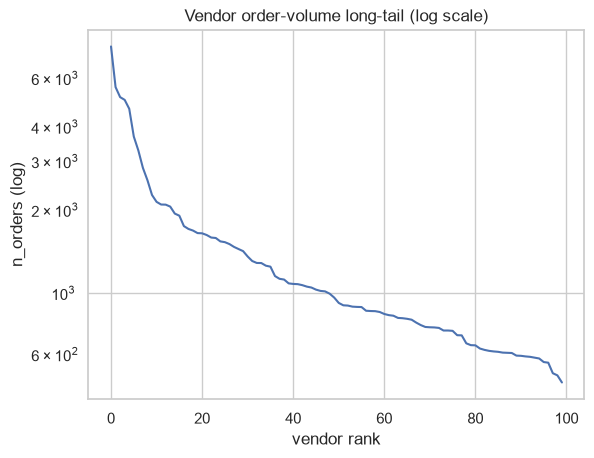

In [16]:
vendor_counts = orders.groupby("vendor_id").size().sort_values(ascending=False)
cust_counts = orders.groupby("customer_id").size()
cold_vendors = (vendor_counts <= 5).sum()
cold_customers = (cust_counts <= 1).sum()
print("vendors with <=5 orders:", cold_vendors, f"({cold_vendors/n_vendors:.1%})")
print("customers with only 1 order:", cold_customers, f"({cold_customers/n_customers:.1%})")

vendor_counts.reset_index(drop=True).plot(logy=True, title="Vendor order-volume long-tail (log scale)")
plt.xlabel("vendor rank"); plt.ylabel("n_orders (log)"); plt.show()

## 11. Summary

- Shape: 135,303 orders, 34,674 customers (train), 100 vendors, 59,503 saved locations.
- Small vendor pool (100) vs large customer base — very different sparsity profile than MovieLens/NYC data (fewer items, way more users per item).
- Missing: `vendor_rating`/`driver_rating` only on unrated orders (expected, `is_rated` flag already tracks this); `dob` heavy missing in customers, avoid using directly as feature without imputation strategy.
- Duplicates found: 81 duplicate `akeed_order_id`, 151 duplicate customer ids in customers table — needs dedup decision before join (keep latest by `created_at`, or investigate if legit repeat exports).
- Data quality: `deliverydistance <= 0` on 55,613 rows (41% of orders) — much larger than a minor edge case, needs its own handling, not simple filter.
- Location coordinates 100% fall outside real Oman bbox — confirmed synthetic/anonymized GPS, not usable for real-world geo-distance features.
- `grand_total`/`item_count` distributions reasonable after clipping; 683 orders with `grand_total <= 0` to filter.
- 3,276 `customer_id` in orders missing from customers table (test-set customers, expected — train/test split boundary).
- No single labeled target column — task defined by reconstructing customer x vendor interaction (matches original competition: predict LOCATION x VENDOR pair likelihood).
- customer x vendor: 27,445 customers, 100 vendors, sparsity 97.4%. No vendor cold-start (0 vendors with ≤5 orders — pool too small/popular for that). Heavy customer cold-start: 36.1% of customers have only 1 order ever.
- Good direct match for this project's goal (next-best-product recommendation) — most "native" rec dataset among all pulled so far, but needs real cleanup work (dup IDs, distance=0 rows, synthetic coords) before modeling, more than MovieLens/NYC did.